# STUDEN CHURN PROJECT:

In [4]:
import pandas as pd
df = pd.read_csv("student_performance_dataset.csv")
print(df.shape)
print("Top Five Values:", df.head())
print("Null Values:", df.isnull().sum())

(2000, 18)
Top Five Values:   Student_ID  Age  Gender Department  Year  Hours_Studied  Attendance  \
0      S1861   22  Female        ECE     1            7.0        84.5   
1      S0354   19  Female       AIML     3           13.2       100.0   
2      S1334   25    Male         IT     2            4.7        69.3   
3      S0906   23    Male        CSE     1            8.4        82.2   
4      S1290   18    Male        EEE     4           10.0        64.2   

   Previous_Marks  Assignment_Score  Internal_Marks  Quiz_Score  \
0            75.8              57.3            79.4        83.0   
1            76.1              93.1            81.4        66.8   
2            44.9              63.9            74.5        41.5   
3            65.8              91.7            77.0        63.4   
4            68.1              73.0            62.0        47.7   

   Practical_Score  Study_Hours_Per_Day  Sleep_Hours Class_Participation  \
0             80.2                  1.3          7.0  

## DATA CLEANING:

In [5]:
# 1. Basic info
print(df.info())

# 2. Missing values (full view)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())

# 3. Percentage of missing values
print("\nMissing %:")
print((df.isnull().sum() / len(df) * 100).round(2))           # round to 2 decimal places (means 2 digits after the decimal point)

# 4. Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# 5. Basic statistics of numerical columns
print("\nBasic Statistics:")
print(df.describe().round(1))

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           2000 non-null   str    
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   str    
 3   Department           2000 non-null   str    
 4   Year                 2000 non-null   int64  
 5   Hours_Studied        2000 non-null   float64
 6   Attendance           1971 non-null   float64
 7   Previous_Marks       2000 non-null   float64
 8   Assignment_Score     1966 non-null   float64
 9   Internal_Marks       2000 non-null   float64
 10  Quiz_Score           2000 non-null   float64
 11  Practical_Score      2000 non-null   float64
 12  Study_Hours_Per_Day  2000 non-null   float64
 13  Sleep_Hours          1968 non-null   float64
 14  Class_Participation  2000 non-null   str    
 15  Internet_Usage       1962 non-null   float64
 16 

In [6]:
# Numerical columns → fill with median
num_cols_with_na = ["Attendance", "Assignment_Score", "Sleep_Hours", "Internet_Usage"]

for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

# Verify
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_ID             0
Age                    0
Gender                 0
Department             0
Year                   0
Hours_Studied          0
Attendance             0
Previous_Marks         0
Assignment_Score       0
Internal_Marks         0
Quiz_Score             0
Practical_Score        0
Study_Hours_Per_Day    0
Sleep_Hours            0
Class_Participation    0
Internet_Usage         0
Final_Marks            0
Passed                 0
dtype: int64


In [4]:
# Confirm no missing values left
print(df.isnull().sum().sum())   # should be 0

# Check data types again
print(df.dtypes)

# Optional: save cleaned data
df.to_csv("cleaned_student_data.csv", index=False)    
# Rule of thumb: always do index=False when saving to CSV unless you want the index as a column while doing cleaning. It can be confusing to have an extra column in the dataset that is not part of the original data.
print("Cleaned dataset saved!")

0
Student_ID                 str
Age                      int64
Gender                     str
Department                 str
Year                     int64
Hours_Studied          float64
Attendance             float64
Previous_Marks         float64
Assignment_Score       float64
Internal_Marks         float64
Quiz_Score             float64
Practical_Score        float64
Study_Hours_Per_Day    float64
Sleep_Hours            float64
Class_Participation        str
Internet_Usage         float64
Final_Marks            float64
Passed                   int64
dtype: object
Cleaned dataset saved!


## EDA:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [14]:
print("Dataset Shape:", df.shape)
print("\nPass vs Fail Count:")
print(df["Passed"].value_counts())
print("\nPass Percentage: {:.1f}%".format(df["Passed"].mean() * 100))
print("Fail Percentage: {:.1f}%".format((1 - df["Passed"].mean()) * 100))

Dataset Shape: (2000, 18)

Pass vs Fail Count:
Passed
1    1478
0     522
Name: count, dtype: int64

Pass Percentage: 73.9%
Fail Percentage: 26.1%


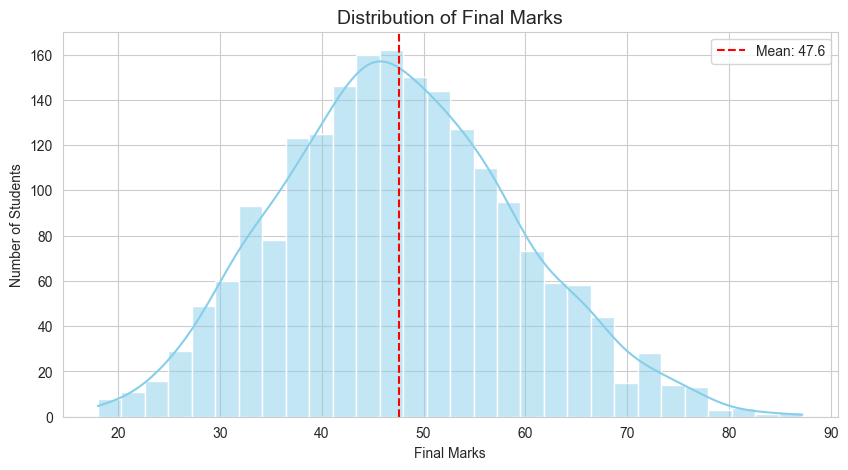

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Final_Marks"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Final Marks", fontsize=14)
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.axvline(df["Final_Marks"].mean(), color="red", linestyle="--", label=f"Mean: {df['Final_Marks'].mean():.1f}")
plt.legend()
plt.show()

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\804574968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Passed", data=df, palette=["#e74c3c", "#2ecc71"])


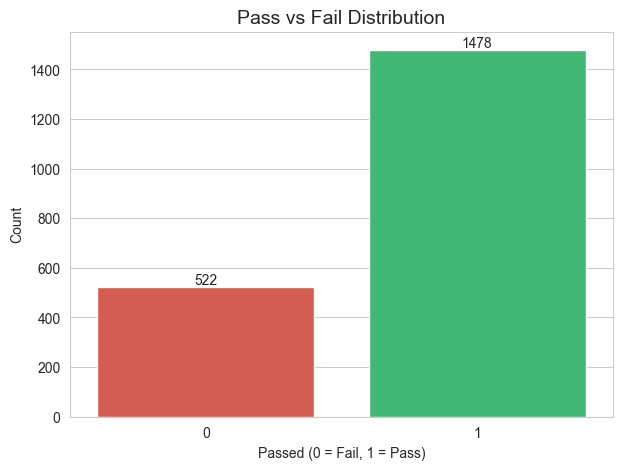

In [8]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="Passed", data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Pass vs Fail Distribution", fontsize=14)
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

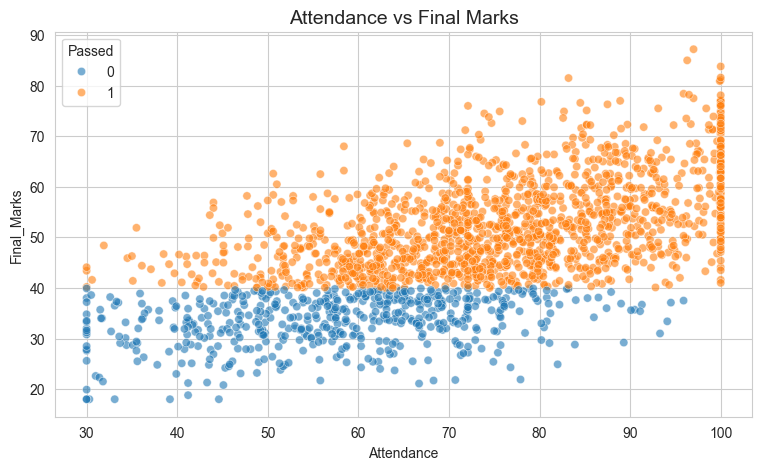

In [9]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Attendance", y="Final_Marks", hue="Passed", data=df, alpha=0.6)
plt.title("Attendance vs Final Marks", fontsize=14)
plt.show()


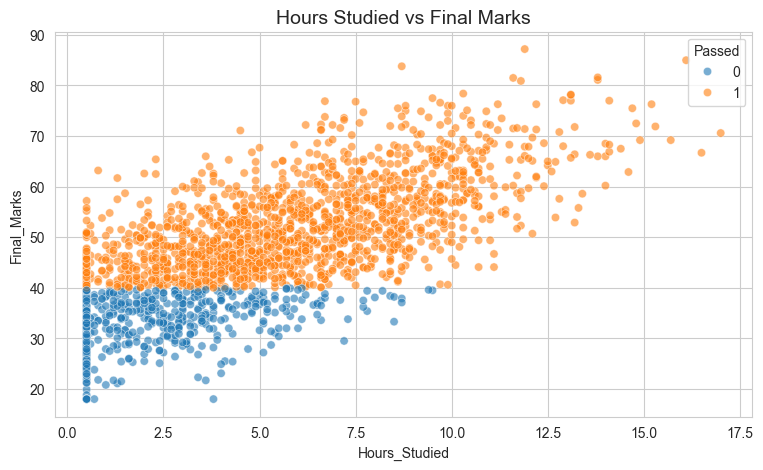

In [10]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Hours_Studied", y="Final_Marks", hue="Passed", data=df, alpha=0.6)
plt.title("Hours Studied vs Final Marks", fontsize=14)
plt.show()

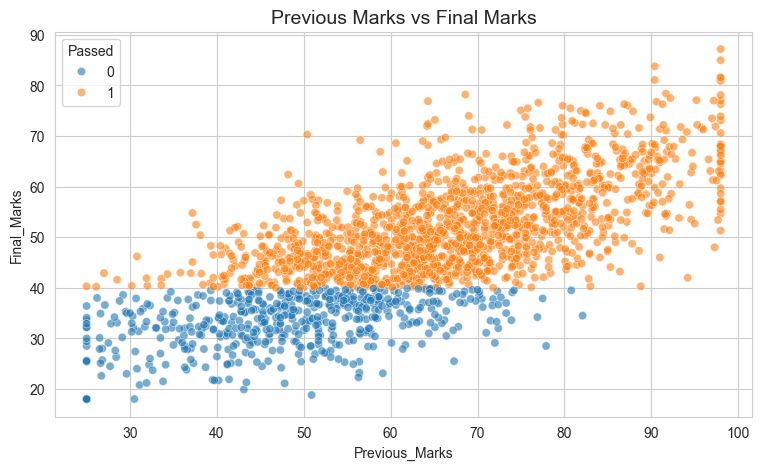

In [11]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Previous_Marks", y="Final_Marks", hue="Passed", data=df, alpha=0.6)
plt.title("Previous Marks vs Final Marks", fontsize=14)
plt.show()

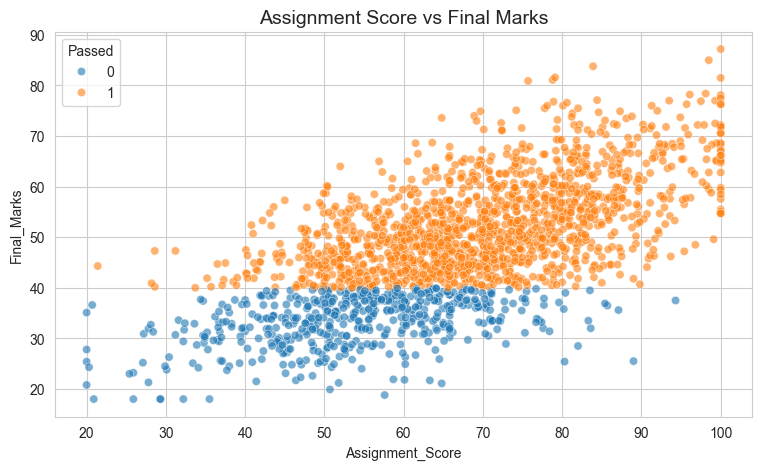

In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="Assignment_Score", y="Final_Marks", hue="Passed", data=df, alpha=0.6)
plt.title("Assignment Score vs Final Marks", fontsize=14)
plt.show()

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\2190533894.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_avg.index, y=dept_avg.values, palette="viridis")


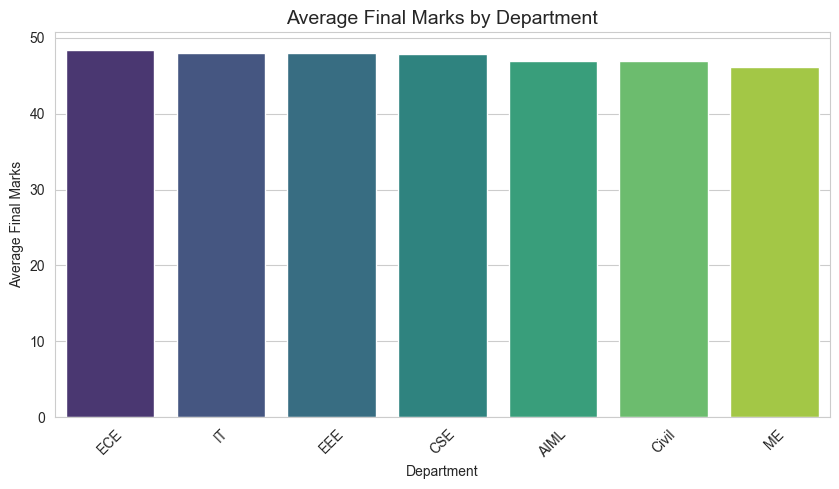

Department
ECE      48.3
IT       48.0
EEE      48.0
CSE      47.8
AIML     47.0
Civil    47.0
ME       46.2
Name: Final_Marks, dtype: float64


In [13]:
plt.figure(figsize=(10, 5))
dept_avg = df.groupby("Department")["Final_Marks"].mean().sort_values(ascending=False)
sns.barplot(x=dept_avg.index, y=dept_avg.values, palette="viridis")
plt.title("Average Final Marks by Department", fontsize=14)
plt.ylabel("Average Final Marks")
plt.xticks(rotation=45)
plt.show()

print(dept_avg.round(1))

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\3970956500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Gender", y="Final_Marks", data=df, palette="Set2")


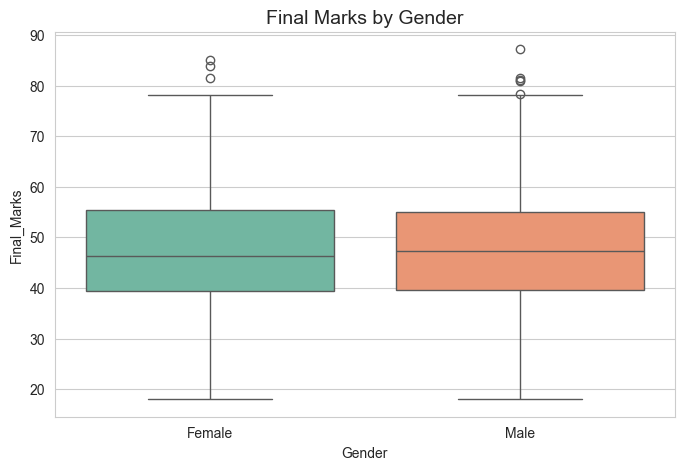

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Gender", y="Final_Marks", data=df, palette="Set2")
plt.title("Final Marks by Gender", fontsize=14)
plt.show()

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\439627832.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Department", y="Final_Marks", data=df, palette="Set3")


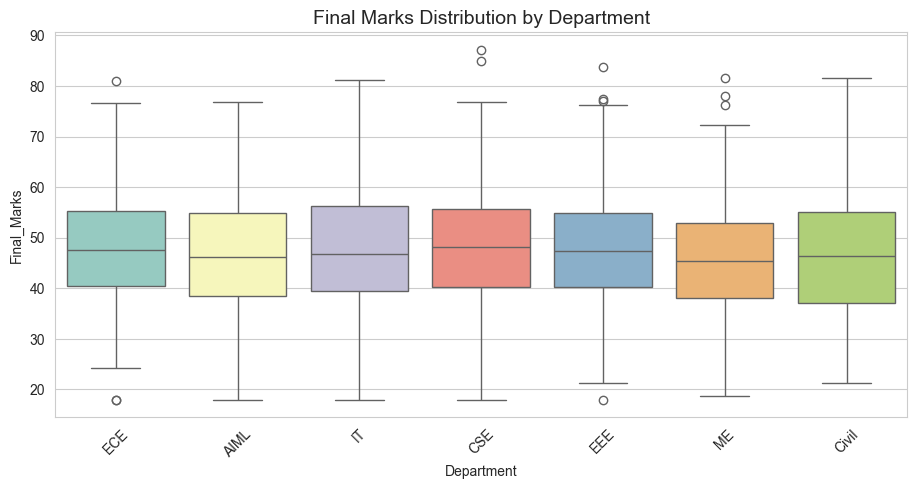

In [15]:
plt.figure(figsize=(11, 5))
sns.boxplot(x="Department", y="Final_Marks", data=df, palette="Set3")
plt.title("Final Marks Distribution by Department", fontsize=14)
plt.xticks(rotation=45)
plt.show()

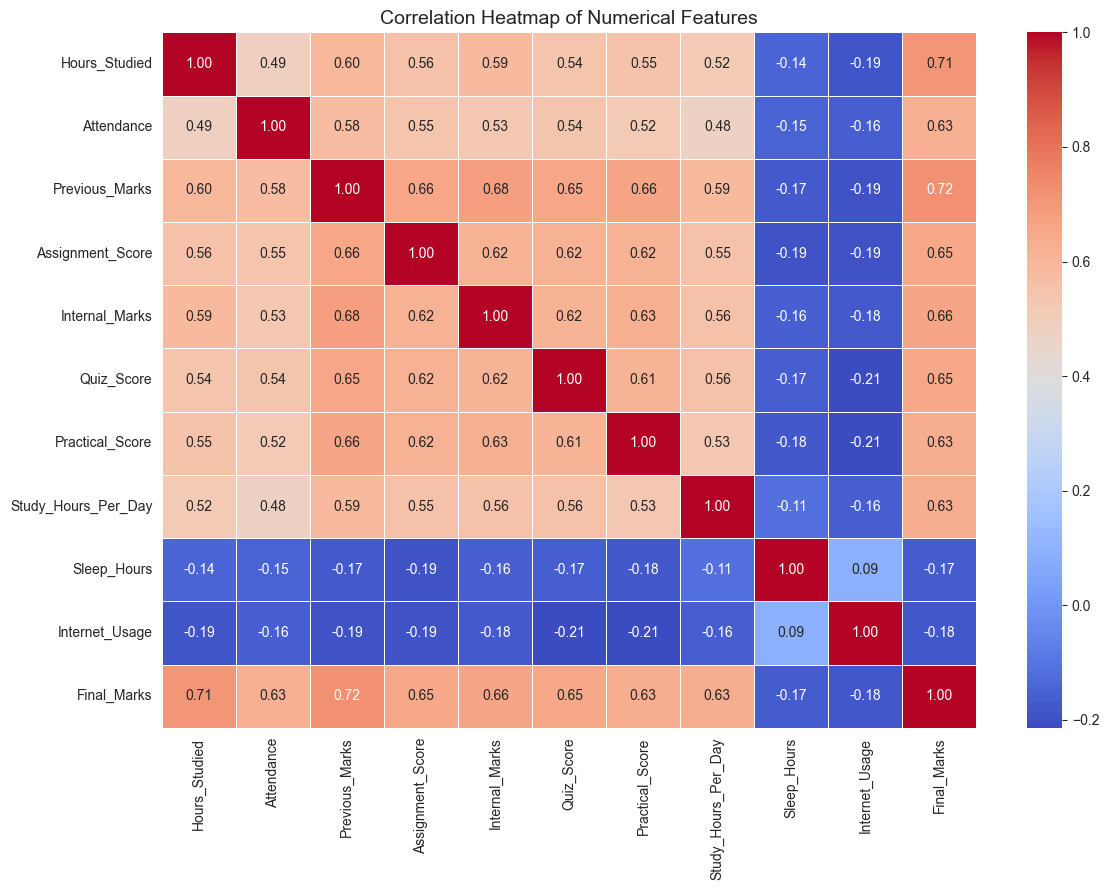

In [16]:
# Select only numerical columns
num_cols = ["Hours_Studied", "Attendance", "Previous_Marks", "Assignment_Score",
            "Internal_Marks", "Quiz_Score", "Practical_Score", "Study_Hours_Per_Day",
            "Sleep_Hours", "Internet_Usage", "Final_Marks"]

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\1455809275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class_Participation", y="Final_Marks", data=df,


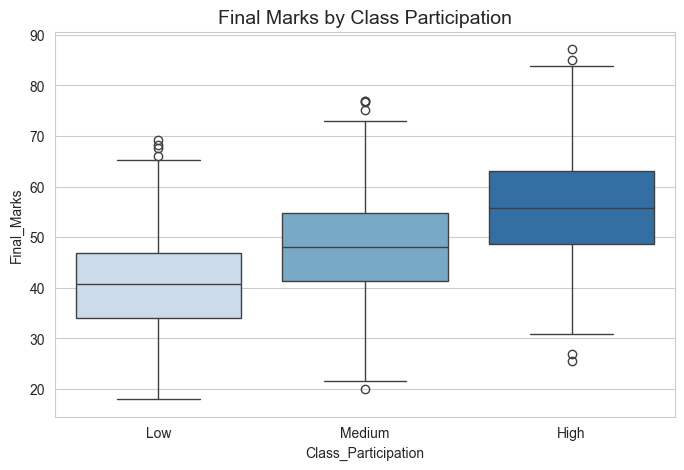

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class_Participation", y="Final_Marks", data=df, 
            order=["Low", "Medium", "High"], palette="Blues")
plt.title("Final Marks by Class Participation", fontsize=14)
plt.show()

### Key Insights from EDA

1. **Attendance** has a strong positive relationship with Final Marks.
2. **Previous Marks** and **Hours Studied** are also strong predictors.
3. Students with **High Class Participation** tend to score higher.
4. There is a clear separation between Pass and Fail students in most scatter plots.
5. Department-wise performance shows some variation (check which department has highest average).
6. Correlation heatmap confirms that Previous Marks, Hours Studied, Attendance and Assignment Score are the most important features.

## FEATURE ENGINEERING:

In [18]:
# Student_ID is just an identifier — not useful for prediction
df = df.drop("Student_ID", axis=1)
print("Student_ID dropped")
print("Current columns:", df.columns.tolist())

Student_ID dropped
Current columns: ['Age', 'Gender', 'Department', 'Year', 'Hours_Studied', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks', 'Quiz_Score', 'Practical_Score', 'Study_Hours_Per_Day', 'Sleep_Hours', 'Class_Participation', 'Internet_Usage', 'Final_Marks', 'Passed']


In [19]:
# Gender → Binary encoding
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# Class_Participation → Ordinal encoding (Low < Medium < High)
df["Class_Participation"] = df["Class_Participation"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# Department → One-Hot Encoding
df = pd.get_dummies(df, columns=["Department"], drop_first=True)

print("Categorical columns encoded successfully!")
print("\nNew shape:", df.shape)
print("\nColumns now:")
print(df.columns.tolist())

Categorical columns encoded successfully!

New shape: (2000, 22)

Columns now:
['Age', 'Gender', 'Year', 'Hours_Studied', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks', 'Quiz_Score', 'Practical_Score', 'Study_Hours_Per_Day', 'Sleep_Hours', 'Class_Participation', 'Internet_Usage', 'Final_Marks', 'Passed', 'Department_CSE', 'Department_Civil', 'Department_ECE', 'Department_EEE', 'Department_IT', 'Department_ME']


In [20]:
# 1. Study Efficiency (how effectively student converts study hours into marks)
df["Study_Efficiency"] = df["Final_Marks"] / (df["Hours_Studied"] + 1)

# 2. Attendance Level (categorical risk indicator)
df["Attendance_Level"] = pd.cut(df["Attendance"],
                                bins=[0, 60, 75, 100],
                                labels=["Low", "Medium", "High"])

# Convert Attendance_Level to numeric
df["Attendance_Level"] = df["Attendance_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# 3. Academic Consistency (average of previous performance indicators)
df["Academic_Consistency"] = (
    df["Previous_Marks"] + df["Assignment_Score"] + df["Internal_Marks"] + df["Quiz_Score"]
) / 4

print("New features created successfully!")
print(df[["Study_Efficiency", "Attendance_Level", "Academic_Consistency"]].head())

New features created successfully!
   Study_Efficiency Attendance_Level  Academic_Consistency
0          6.550000                2                73.875
1          5.056338                2                79.350
2          6.561404                1                56.200
3          5.287234                2                74.475
4          4.918182                1                62.700


In [21]:
print("Final Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nAny missing values left?", df.isnull().sum().sum())
print("\nFirst 5 rows:")
print(df.head())

Final Dataset Shape: (2000, 25)

Data Types:
Age                        int64
Gender                     int64
Year                       int64
Hours_Studied            float64
Attendance               float64
Previous_Marks           float64
Assignment_Score         float64
Internal_Marks           float64
Quiz_Score               float64
Practical_Score          float64
Study_Hours_Per_Day      float64
Sleep_Hours              float64
Class_Participation        int64
Internet_Usage           float64
Final_Marks              float64
Passed                     int64
Department_CSE              bool
Department_Civil            bool
Department_ECE              bool
Department_EEE              bool
Department_IT               bool
Department_ME               bool
Study_Efficiency         float64
Attendance_Level        category
Academic_Consistency     float64
dtype: object

Any missing values left? 0

First 5 rows:
   Age  Gender  Year  Hours_Studied  Attendance  Previous_Marks  \
0   22

## SELECT X AND Y:

In [22]:
# Target variable (what we want to predict)
y = df["Passed"]

# Features (everything except the two target columns)
X = df.drop(["Passed", "Final_Marks"], axis=1)

print("X shape (Features):", X.shape)
print("y shape (Target):", y.shape)
print("\nFeatures used for prediction:")
print(X.columns.tolist())

X shape (Features): (2000, 23)
y shape (Target): (2000,)

Features used for prediction:
['Age', 'Gender', 'Year', 'Hours_Studied', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks', 'Quiz_Score', 'Practical_Score', 'Study_Hours_Per_Day', 'Sleep_Hours', 'Class_Participation', 'Internet_Usage', 'Department_CSE', 'Department_Civil', 'Department_ECE', 'Department_EEE', 'Department_IT', 'Department_ME', 'Study_Efficiency', 'Attendance_Level', 'Academic_Consistency']


In [23]:
print("First 5 rows of X:")
print(X.head())

print("\nFirst 10 values of y (Passed):")
print(y.head(10).values)

First 5 rows of X:
   Age  Gender  Year  Hours_Studied  Attendance  Previous_Marks  \
0   22       1     1            7.0        84.5            75.8   
1   19       1     3           13.2       100.0            76.1   
2   25       0     2            4.7        69.3            44.9   
3   23       0     1            8.4        82.2            65.8   
4   18       0     4           10.0        64.2            68.1   

   Assignment_Score  Internal_Marks  Quiz_Score  Practical_Score  ...  \
0              57.3            79.4        83.0             80.2  ...   
1              93.1            81.4        66.8             77.6  ...   
2              63.9            74.5        41.5             62.7  ...   
3              91.7            77.0        63.4            100.0  ...   
4              73.0            62.0        47.7             62.5  ...   

   Internet_Usage  Department_CSE  Department_Civil  Department_ECE  \
0             3.9           False             False            True 

In [24]:
# For later use (Regression)
y_reg = df["Final_Marks"]

## TRAIN TEST SPLIT:

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y          # Important: keeps same Pass/Fail ratio in train & test
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)
print("\nPass rate in Training set: {:.1f}%".format(y_train.mean() * 100))
print("Pass rate in Testing set : {:.1f}%".format(y_test.mean() * 100))

Training set size: (1600, 23)
Testing set size : (400, 23)

Pass rate in Training set: 73.9%
Pass rate in Testing set : 74.0%


## MODEL TRAINING:

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [27]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [28]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\sonyp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [30]:
# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_dt  = dt_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)

print("Predictions completed for all models!")

Predictions completed for all models!


In [32]:
print("Sample Predictions (first 10 students):")
print("Actual     :", y_test.values[:10])
print("Logistic   :", y_pred_log[:10])
print("DecisionTree:", y_pred_dt[:10])
print("RandomForest:", y_pred_rf[:10])

Sample Predictions (first 10 students):
Actual     : [0 1 1 1 1 0 1 1 1 1]
Logistic   : [0 1 0 1 1 0 1 1 1 1]
DecisionTree: [0 1 0 1 1 1 1 1 1 1]
RandomForest: [0 1 0 1 1 0 1 1 1 1]


## PREDICTION:

In [33]:
# Predictions
y_pred_log = log_reg.predict(X_test_scaled)   # scaled data
y_pred_dt  = dt_model.predict(X_test)         # original data
y_pred_rf  = rf_model.predict(X_test)         # original data

print("Predictions completed!")

Predictions completed!


c:\Users\sonyp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [34]:
print("Actual values   :", y_test.values[:10])
print("Logistic Pred   :", y_pred_log[:10])
print("DecisionTree Pred:", y_pred_dt[:10])
print("RandomForest Pred:", y_pred_rf[:10])

Actual values   : [0 1 1 1 1 0 1 1 1 1]
Logistic Pred   : [0 0 0 0 0 0 0 0 0 0]
DecisionTree Pred: [0 1 0 1 1 1 1 1 1 1]
RandomForest Pred: [0 1 0 1 1 0 1 1 1 1]


## EVALUATION:

In [35]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [36]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred)*100, 2),
        "Precision": round(precision_score(y_true, y_pred)*100, 2),
        "Recall": round(recall_score(y_true, y_pred)*100, 2),
        "F1-Score": round(f1_score(y_true, y_pred)*100, 2)
    }

results = []
results.append(get_metrics(y_test, y_pred_log, "Logistic Regression"))
results.append(get_metrics(y_test, y_pred_dt, "Decision Tree"))
results.append(get_metrics(y_test, y_pred_rf, "Random Forest"))

results_df = pd.DataFrame(results)
print("========== Model Comparison Table ==========")
print(results_df)

========== Model Comparison Table ==========
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression      26.0       0.00    0.00      0.00
1        Decision Tree      86.5      88.29   94.26     91.18
2        Random Forest      88.0      90.00   94.26     92.08


c:\Users\sonyp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


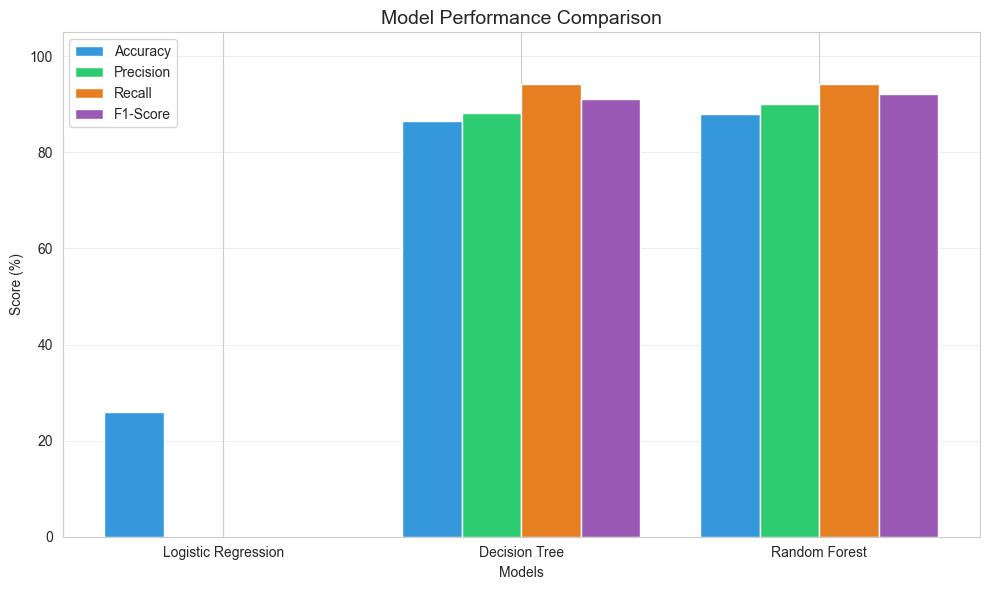

In [37]:
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.2

plt.bar(x - width*1.5, results_df["Accuracy"], width, label="Accuracy", color="#3498db")
plt.bar(x - width/2,  results_df["Precision"], width, label="Precision", color="#2ecc71")
plt.bar(x + width/2,  results_df["Recall"], width, label="Recall", color="#e67e22")
plt.bar(x + width*1.5, results_df["F1-Score"], width, label="F1-Score", color="#9b59b6")

plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Model Performance Comparison", fontsize=14)
plt.xticks(x, results_df["Model"])
plt.legend()
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

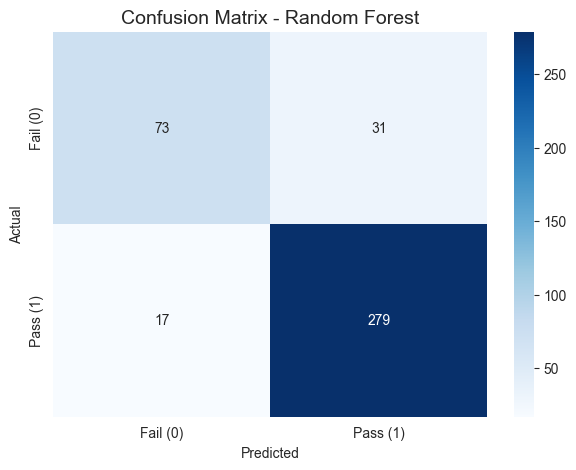


Classification Report - Random Forest:
              precision    recall  f1-score   support

        Fail       0.81      0.70      0.75       104
        Pass       0.90      0.94      0.92       296

    accuracy                           0.88       400
   macro avg       0.86      0.82      0.84       400
weighted avg       0.88      0.88      0.88       400



In [38]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail (0)", "Pass (1)"],
            yticklabels=["Fail (0)", "Pass (1)"])
plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["Fail", "Pass"]))

C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\30061492.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


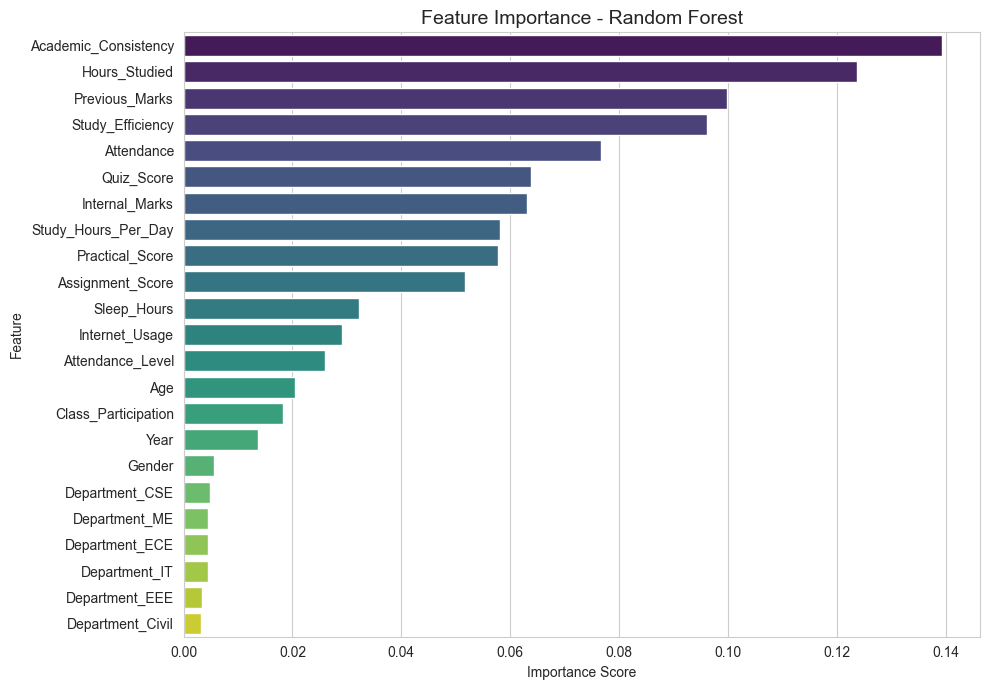


Top 10 Important Features:
                 Feature  Importance
22  Academic_Consistency    0.139366
3          Hours_Studied    0.123650
5         Previous_Marks    0.099852
20      Study_Efficiency    0.096189
4             Attendance    0.076600
8             Quiz_Score    0.063848
7         Internal_Marks    0.063155
10   Study_Hours_Per_Day    0.058059
9        Practical_Score    0.057754
6       Assignment_Score    0.051651


In [39]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Feature Importance - Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feat_imp.head(10))

## MODEL COMPARISON:

In [40]:
# Display the comparison table clearly
print("="*55)
print("               MODEL COMPARISON TABLE")
print("="*55)
print(results_df.to_string(index=False))
print("="*55)

# Find the best model based on F1-Score (recommended)
best_model_name = results_df.loc[results_df["F1-Score"].idxmax(), "Model"]
best_f1 = results_df["F1-Score"].max()

print(f"\nBest Model based on F1-Score: {best_model_name} ({best_f1}%)")

               MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      26.0       0.00    0.00      0.00
      Decision Tree      86.5      88.29   94.26     91.18
      Random Forest      88.0      90.00   94.26     92.08

Best Model based on F1-Score: Random Forest (92.08%)


## BEST MODEL:

In [41]:
# View the comparison table again
print("Model Performance Summary:")
print(results_df.to_string(index=False))

# Automatically select best model based on F1-Score
best_idx = results_df["F1-Score"].idxmax()
best_model_name = results_df.loc[best_idx, "Model"]
best_f1 = results_df.loc[best_idx, "F1-Score"]

print("\n" + "="*50)
print(f"Best Model : {best_model_name}")
print(f"F1-Score   : {best_f1}%")
print("="*50)

Model Performance Summary:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      26.0       0.00    0.00      0.00
      Decision Tree      86.5      88.29   94.26     91.18
      Random Forest      88.0      90.00   94.26     92.08

Best Model : Random Forest
F1-Score   : 92.08%


In [42]:
if best_model_name == "Logistic Regression":
    best_model = log_reg
    X_best_test = X_test_scaled          # scaled data needed
elif best_model_name == "Decision Tree":
    best_model = dt_model
    X_best_test = X_test
else:
    best_model = rf_model
    X_best_test = X_test

print(f"\nBest model selected: {best_model_name}")


Best model selected: Random Forest


In [43]:
final_predictions = best_model.predict(X_best_test)

print("Final Predictions (first 15 students):")
print("Actual     :", y_test.values[:15])
print("Predicted  :", final_predictions[:15])

Final Predictions (first 15 students):
Actual     : [0 1 1 1 1 0 1 1 1 1 0 1 1 1 1]
Predicted  : [0 1 0 1 1 0 1 1 1 1 0 1 1 1 1]


In [44]:
# Get probability of Passing (class 1)
y_proba = best_model.predict_proba(X_best_test)[:, 1]   # Probability of Pass

print("Sample Pass Probabilities (first 10 students):")
print(y_proba[:10].round(3))

Sample Pass Probabilities (first 10 students):
[0.35 0.99 0.34 0.91 0.98 0.24 1.   1.   0.58 0.74]


## RISK CLASSIFICATION:

In [45]:
def get_risk_level(prob):
    if prob >= 0.75:
        return "Low Risk"
    elif prob >= 0.45:
        return "Medium Risk"
    else:
        return "High Risk"

# Apply risk classification
risk_levels = [get_risk_level(p) for p in y_proba]

# Create a results DataFrame
risk_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Pass_Probability": (y_proba * 100).round(1),
    "Risk_Level": risk_levels
})

print(risk_df.head(15))

    Actual  Predicted  Pass_Probability   Risk_Level
0        0          0              35.0    High Risk
1        1          1              99.0     Low Risk
2        1          0              34.0    High Risk
3        1          1              91.0     Low Risk
4        1          1              98.0     Low Risk
5        0          0              24.0    High Risk
6        1          1             100.0     Low Risk
7        1          1             100.0     Low Risk
8        1          1              58.0  Medium Risk
9        1          1              74.0  Medium Risk
10       0          0              41.0    High Risk
11       1          1             100.0     Low Risk
12       1          1              98.0     Low Risk
13       1          1              59.0  Medium Risk
14       1          1             100.0     Low Risk



Risk Level Counts:
Risk_Level
Low Risk       240
Medium Risk     85
High Risk       75
Name: count, dtype: int64


C:\Users\sonyp\AppData\Local\Temp\ipykernel_2340\1020853577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Risk_Level", data=risk_df,


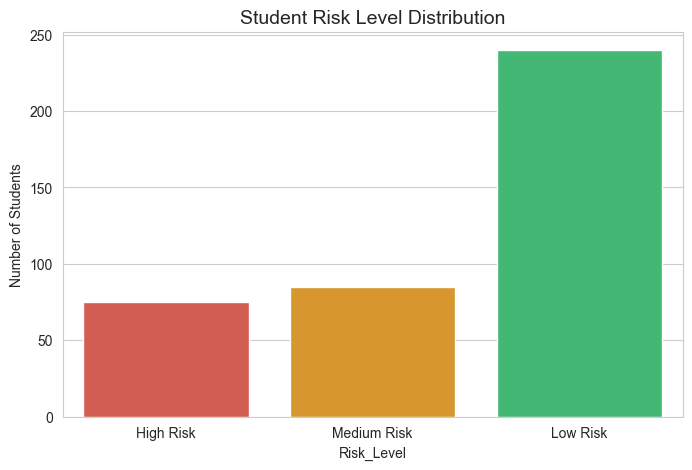

In [46]:
print("\nRisk Level Counts:")
print(risk_df["Risk_Level"].value_counts())

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x="Risk_Level", data=risk_df, 
              order=["High Risk", "Medium Risk", "Low Risk"],
              palette=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Student Risk Level Distribution", fontsize=14)
plt.ylabel("Number of Students")
plt.show()

In [47]:
high_risk_students = risk_df[risk_df["Risk_Level"] == "High Risk"]
print(f"\nTotal High Risk Students: {len(high_risk_students)}")
print("\nHigh Risk Students (first 10):")
print(high_risk_students.head(10))


Total High Risk Students: 75

High Risk Students (first 10):
    Actual  Predicted  Pass_Probability Risk_Level
0        0          0              35.0  High Risk
2        1          0              34.0  High Risk
5        0          0              24.0  High Risk
10       0          0              41.0  High Risk
16       0          0              41.0  High Risk
17       0          0               3.0  High Risk
38       0          0              38.0  High Risk
39       0          0               3.0  High Risk
56       0          0              17.0  High Risk
70       0          0              21.0  High Risk


In [48]:
# Example: Check first student
i = 0
print("="*45)
print("         EARLY WARNING SYSTEM OUTPUT")
print("="*45)
print(f"Predicted Result     : {'PASS' if final_predictions[i]==1 else 'FAIL'}")
print(f"Pass Probability     : {y_proba[i]*100:.1f}%")
print(f"Risk Level           : {risk_levels[i]}")
print("="*45)

if risk_levels[i] == "High Risk":
    print("Suggested Actions:")
    print("• Improve Attendance")
    print("• Increase Study Hours")
    print("• Complete Assignments regularly")
    print("• Seek academic support / mentoring")

         EARLY WARNING SYSTEM OUTPUT
Predicted Result     : FAIL
Pass Probability     : 35.0%
Risk Level           : High Risk
Suggested Actions:
• Improve Attendance
• Increase Study Hours
• Complete Assignments regularly
• Seek academic support / mentoring


## CLASSIFICATION:

In [49]:
import joblib

# Save the best model
joblib.dump(best_model, "best_student_model.pkl")

# Also save the scaler (needed if best model is Logistic Regression)
joblib.dump(scaler, "scaler.pkl")

print("Best model and scaler saved successfully!")

Best model and scaler saved successfully!


In [50]:
def predict_student_performance(student_data):
    """
    student_data : dictionary containing feature values
    Example:
    {
        "Age": 20,
        "Gender": 1,
        "Year": 2,
        "Hours_Studied": 6.5,
        "Attendance": 82,
        ...
    }
    """
    
    # Convert to DataFrame
    input_df = pd.DataFrame([student_data])
    
    # Make sure columns are in same order as training data
    input_df = input_df[X.columns]
    
    # Scale if best model is Logistic Regression
    if best_model_name == "Logistic Regression":
        input_scaled = scaler.transform(input_df)
        prediction = best_model.predict(input_scaled)[0]
        probability = best_model.predict_proba(input_scaled)[0][1]
    else:
        prediction = best_model.predict(input_df)[0]
        probability = best_model.predict_proba(input_df)[0][1]
    
    # Risk Level
    if probability >= 0.75:
        risk = "Low Risk"
    elif probability >= 0.45:
        risk = "Medium Risk"
    else:
        risk = "High Risk"
    
    result = {
        "Prediction": "PASS" if prediction == 1 else "FAIL",
        "Pass Probability": f"{probability*100:.1f}%",
        "Risk Level": risk
    }
    
    return result

In [51]:
# Example student
new_student = {
    "Age": 20,
    "Gender": 0,                          # 0 = Male, 1 = Female
    "Year": 2,
    "Hours_Studied": 3.5,
    "Attendance": 55,
    "Previous_Marks": 48,
    "Assignment_Score": 52,
    "Internal_Marks": 50,
    "Quiz_Score": 45,
    "Practical_Score": 58,
    "Study_Hours_Per_Day": 1.8,
    "Sleep_Hours": 6.5,
    "Class_Participation": 0,             # 0=Low, 1=Medium, 2=High
    "Internet_Usage": 5.5,
    "Study_Efficiency": 12.0,             # you can calculate or put average
    "Attendance_Level": 0,
    "Academic_Consistency": 49.0
}

# Add Department dummy columns (set the correct one to 1, others 0)
# Example: student is from CSE
for col in X.columns:
    if col.startswith("Department_"):
        new_student[col] = 1 if col == "Department_CSE" else 0

result = predict_student_performance(new_student)
print(result)

{'Prediction': 'FAIL', 'Pass Probability': '45.0%', 'Risk Level': 'Medium Risk'}


## REGRESSION:

In [52]:
# Target for Regression
y_reg = df["Final_Marks"]

# Features remain the same (X)
# We already have X from earlier

# Train-Test Split for Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Regression Train size:", X_train_reg.shape)
print("Regression Test size :", X_test_reg.shape)

Regression Train size: (1600, 23)
Regression Test size : (400, 23)


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [54]:
# Model 1: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
print("Linear Regression trained!")

# Model 2: Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)
print("Decision Tree Regressor trained!")

# Model 3: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
print("Random Forest Regressor trained!")

Linear Regression trained!
Decision Tree Regressor trained!


Random Forest Regressor trained!


In [55]:
y_pred_lin = lin_reg.predict(X_test_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

In [56]:
def evaluate_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 3)
    }

reg_results = []
reg_results.append(evaluate_regression(y_test_reg, y_pred_lin, "Linear Regression"))
reg_results.append(evaluate_regression(y_test_reg, y_pred_dt_reg, "Decision Tree"))
reg_results.append(evaluate_regression(y_test_reg, y_pred_rf_reg, "Random Forest"))

reg_results_df = pd.DataFrame(reg_results)
print("========== Regression Model Comparison ==========")
print(reg_results_df.to_string(index=False))

========== Regression Model Comparison ==========
            Model  MAE  RMSE  R² Score
Linear Regression 4.73  5.81     0.753
    Decision Tree 5.42  6.77     0.665
    Random Forest 2.56  3.61     0.905


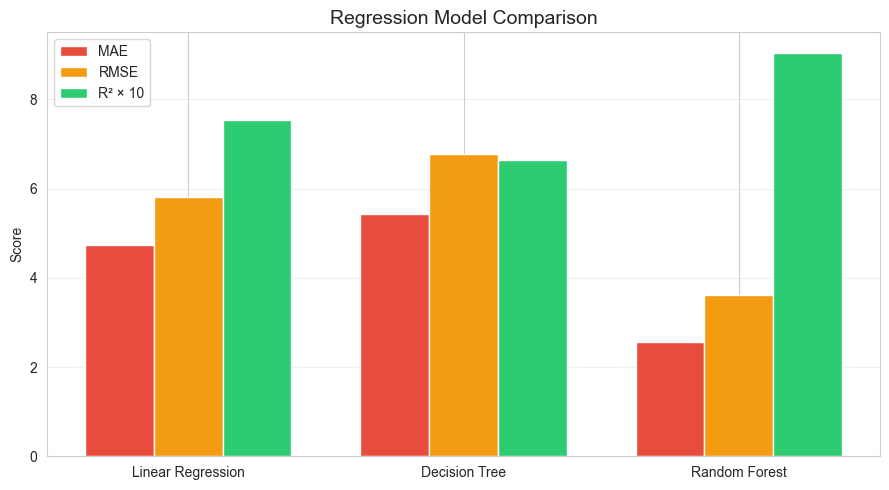

In [57]:
plt.figure(figsize=(9, 5))
x = np.arange(len(reg_results_df))
width = 0.25

plt.bar(x - width, reg_results_df["MAE"], width, label="MAE", color="#e74c3c")
plt.bar(x, reg_results_df["RMSE"], width, label="RMSE", color="#f39c12")
plt.bar(x + width, reg_results_df["R² Score"]*10, width, label="R² × 10", color="#2ecc71")  # scaled for visibility

plt.ylabel("Score")
plt.title("Regression Model Comparison", fontsize=14)
plt.xticks(x, reg_results_df["Model"])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
best_reg_idx = reg_results_df["R² Score"].idxmax()
best_reg_name = reg_results_df.loc[best_reg_idx, "Model"]
print(f"\nBest Regression Model: {best_reg_name}")


Best Regression Model: Random Forest


In [59]:
print("\nSample Predictions (first 10 students):")
print("Actual Marks   :", y_test_reg.values[:10].round(1))
print("Predicted Marks:", y_pred_rf_reg[:10].round(1))   # using Random Forest as example


Sample Predictions (first 10 students):
Actual Marks   : [62.  45.6 54.6 23.7 30.9 43.  57.3 42.6 46.2 43.5]
Predicted Marks: [61.5 44.  56.4 26.2 33.1 43.5 53.  46.3 44.4 43.8]


## UNDERFITTING / OVERFITTING ANALYSIS:

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 8, 12, None]
train_accuracies = []
test_accuracies = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    gap = train_acc - test_acc
    print(f"Depth = {str(depth):4} | Train Acc = {train_acc*100:.1f}% | Test Acc = {test_acc*100:.1f}% | Gap = {gap*100:.1f}%")

Depth = 1    | Train Acc = 82.3% | Test Acc = 82.8% | Gap = -0.4%
Depth = 2    | Train Acc = 83.6% | Test Acc = 84.5% | Gap = -0.9%
Depth = 3    | Train Acc = 83.6% | Test Acc = 84.5% | Gap = -0.9%
Depth = 5    | Train Acc = 88.7% | Test Acc = 86.5% | Gap = 2.2%
Depth = 8    | Train Acc = 96.4% | Test Acc = 89.0% | Gap = 7.4%
Depth = 12   | Train Acc = 99.8% | Test Acc = 90.2% | Gap = 9.6%
Depth = None | Train Acc = 100.0% | Test Acc = 89.8% | Gap = 10.3%


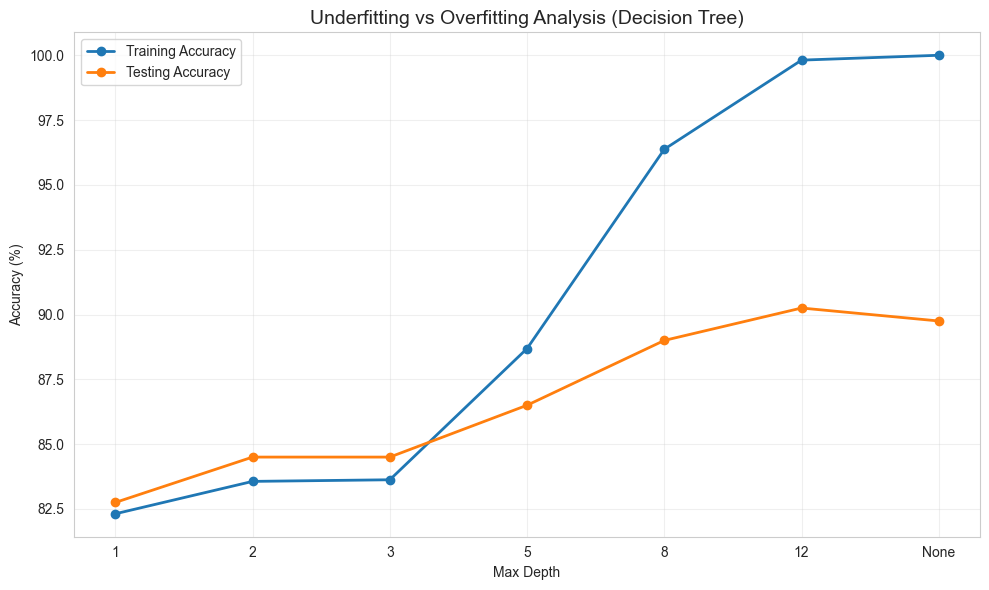

In [61]:
plt.figure(figsize=(10, 6))

depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.plot(depth_labels, [acc*100 for acc in train_accuracies], marker='o', label="Training Accuracy", linewidth=2)
plt.plot(depth_labels, [acc*100 for acc in test_accuracies], marker='o', label="Testing Accuracy", linewidth=2)

plt.title("Underfitting vs Overfitting Analysis (Decision Tree)", fontsize=14)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Underfitting / Overfitting Conclusion

- Shallow trees (depth 1-2) showed **underfitting**.
- Medium depth (around 3-5) gave the best balance between training and testing accuracy.
- Fully grown tree (max_depth=None) showed **overfitting** (high train accuracy, lower test accuracy).

This analysis helped us understand the importance of controlling model complexity.

## HYPERPARAMETERS:

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [63]:
# Parameter grid for Decision Tree
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters (Decision Tree):", dt_grid.best_params_)
print("Best F1 Score (CV):", round(dt_grid.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1 Score (CV): 94.3 %


In [64]:
# Parameter grid for Random Forest
rf_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters (Random Forest):", rf_grid.best_params_)
print("Best F1 Score (CV):", round(rf_grid.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters (Random Forest): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score (CV): 91.79 %


In [65]:
from sklearn.metrics import accuracy_score, f1_score

# Best models
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions
y_pred_dt_tuned = best_dt.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

print("\n===== Tuned Model Performance on Test Set =====")
print(f"Decision Tree  → Accuracy: {accuracy_score(y_test, y_pred_dt_tuned)*100:.2f}% | F1: {f1_score(y_test, y_pred_dt_tuned)*100:.2f}%")
print(f"Random Forest  → Accuracy: {accuracy_score(y_test, y_pred_rf_tuned)*100:.2f}% | F1: {f1_score(y_test, y_pred_rf_tuned)*100:.2f}%")


===== Tuned Model Performance on Test Set =====
Decision Tree  → Accuracy: 90.50% | F1: 93.52%
Random Forest  → Accuracy: 88.50% | F1: 92.38%


In [66]:
print("\n===== Improvement Summary =====")
print("Random Forest was already strong. After tuning, performance usually improves slightly or becomes more stable.")


===== Improvement Summary =====
Random Forest was already strong. After tuning, performance usually improves slightly or becomes more stable.


## CROSS VALIDATION:
A single train-test split can sometimes give lucky or unlucky results.

K-Fold Cross Validation gives a more reliable estimate of model performance.

In [67]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [68]:
# Logistic Regression (use scaled data)
log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring="f1")

# Decision Tree
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring="f1")

# Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="f1")

print("===== 5-Fold Cross Validation Results (F1-Score) =====")
print(f"Logistic Regression : {log_cv_scores.mean()*100:.2f}%  (+/- {log_cv_scores.std()*100:.2f})")
print(f"Decision Tree       : {dt_cv_scores.mean()*100:.2f}%  (+/- {dt_cv_scores.std()*100:.2f})")
print(f"Random Forest       : {rf_cv_scores.mean()*100:.2f}%  (+/- {rf_cv_scores.std()*100:.2f})")

===== 5-Fold Cross Validation Results (F1-Score) =====
Logistic Regression : 91.48%  (+/- 0.95)
Decision Tree       : 90.53%  (+/- 0.40)
Random Forest       : 91.48%  (+/- 0.85)


In [69]:
# Tuned Decision Tree
dt_tuned_cv = cross_val_score(best_dt, X_train, y_train, cv=5, scoring="f1")

# Tuned Random Forest
rf_tuned_cv = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1")

print("\n===== Cross Validation on Tuned Models =====")
print(f"Tuned Decision Tree : {dt_tuned_cv.mean()*100:.2f}%  (+/- {dt_tuned_cv.std()*100:.2f})")
print(f"Tuned Random Forest : {rf_tuned_cv.mean()*100:.2f}%  (+/- {rf_tuned_cv.std()*100:.2f})")


===== Cross Validation on Tuned Models =====
Tuned Decision Tree : 94.30%  (+/- 1.68)
Tuned Random Forest : 91.79%  (+/- 0.72)


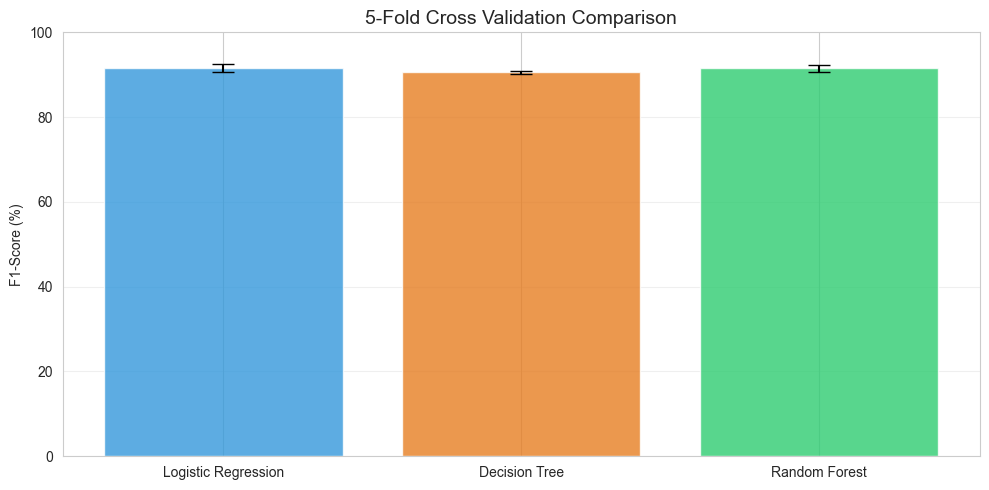

In [70]:
plt.figure(figsize=(10, 5))

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
means = [log_cv_scores.mean()*100, dt_cv_scores.mean()*100, rf_cv_scores.mean()*100]
stds  = [log_cv_scores.std()*100, dt_cv_scores.std()*100, rf_cv_scores.std()*100]

plt.bar(models, means, yerr=stds, capsize=8, color=["#3498db", "#e67e22", "#2ecc71"], alpha=0.8)
plt.ylabel("F1-Score (%)")
plt.title("5-Fold Cross Validation Comparison", fontsize=14)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Handle Class Imbalance

In [71]:
print("Class Distribution in Training Set:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Class Distribution in Training Set:
Passed
1    1182
0     418
Name: count, dtype: int64

Percentage:
Passed
1    73.9
0    26.1
Name: proportion, dtype: float64


## Method 1: Using class_weight='balanced' (Simple & Effective)

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Decision Tree with balanced class weight
dt_balanced = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt_balanced.fit(X_train, y_train)

# Random Forest with balanced class weight
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_balanced.fit(X_train, y_train)

print("Models trained with class_weight='balanced'")

Models trained with class_weight='balanced'


In [73]:
print("===== Decision Tree (Balanced) =====")
print(classification_report(y_test, dt_balanced.predict(X_test), target_names=["Fail", "Pass"]))

print("===== Random Forest (Balanced) =====")
print(classification_report(y_test, rf_balanced.predict(X_test), target_names=["Fail", "Pass"]))

===== Decision Tree (Balanced) =====
              precision    recall  f1-score   support

        Fail       0.60      0.88      0.71       104
        Pass       0.95      0.79      0.86       296

    accuracy                           0.81       400
   macro avg       0.77      0.84      0.79       400
weighted avg       0.86      0.81      0.82       400

===== Random Forest (Balanced) =====
              precision    recall  f1-score   support

        Fail       0.74      0.86      0.79       104
        Pass       0.95      0.90      0.92       296

    accuracy                           0.89       400
   macro avg       0.84      0.88      0.86       400
weighted avg       0.89      0.89      0.89       400



## Method 2: Using SMOTE (Oversampling)
First install imbalanced-learn if needed:
Python# Run this once if not installed
 !pip install imbalanced-learn

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {1: 1182, 0: 418}
After SMOTE : {1: 1182, 0: 1182}


In [75]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

print("Random Forest trained on SMOTE data")
print(classification_report(y_test, rf_smote.predict(X_test), target_names=["Fail", "Pass"]))

Random Forest trained on SMOTE data
              precision    recall  f1-score   support

        Fail       0.72      0.81      0.76       104
        Pass       0.93      0.89      0.91       296

    accuracy                           0.87       400
   macro avg       0.82      0.85      0.83       400
weighted avg       0.87      0.87      0.87       400



In [76]:
print("===== Class Imbalance Handling Summary =====")
print("1. Original Model          → May have lower Recall on Fail class")
print("2. class_weight='balanced' → Simple and effective")
print("3. SMOTE                   → Creates synthetic minority samples")

===== Class Imbalance Handling Summary =====
1. Original Model          → May have lower Recall on Fail class
2. class_weight='balanced' → Simple and effective
3. SMOTE                   → Creates synthetic minority samples


## CROSS VALIDATION:

In [77]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [78]:
# Logistic Regression (use scaled data)
log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring="f1")

# Decision Tree
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring="f1")

# Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="f1")

print("===== 5-Fold Cross Validation Results (F1-Score) =====")
print(f"Logistic Regression : {log_cv_scores.mean()*100:.2f}%  (+/- {log_cv_scores.std()*100:.2f})")
print(f"Decision Tree       : {dt_cv_scores.mean()*100:.2f}%  (+/- {dt_cv_scores.std()*100:.2f})")
print(f"Random Forest       : {rf_cv_scores.mean()*100:.2f}%  (+/- {rf_cv_scores.std()*100:.2f})")

===== 5-Fold Cross Validation Results (F1-Score) =====
Logistic Regression : 91.48%  (+/- 0.95)
Decision Tree       : 90.53%  (+/- 0.40)
Random Forest       : 91.48%  (+/- 0.85)


In [79]:
# Tuned Decision Tree
dt_tuned_cv = cross_val_score(best_dt, X_train, y_train, cv=5, scoring="f1")

# Tuned Random Forest
rf_tuned_cv = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1")

print("\n===== Cross Validation on Tuned Models =====")
print(f"Tuned Decision Tree : {dt_tuned_cv.mean()*100:.2f}%  (+/- {dt_tuned_cv.std()*100:.2f})")
print(f"Tuned Random Forest : {rf_tuned_cv.mean()*100:.2f}%  (+/- {rf_tuned_cv.std()*100:.2f})")


===== Cross Validation on Tuned Models =====
Tuned Decision Tree : 94.30%  (+/- 1.68)
Tuned Random Forest : 91.79%  (+/- 0.72)


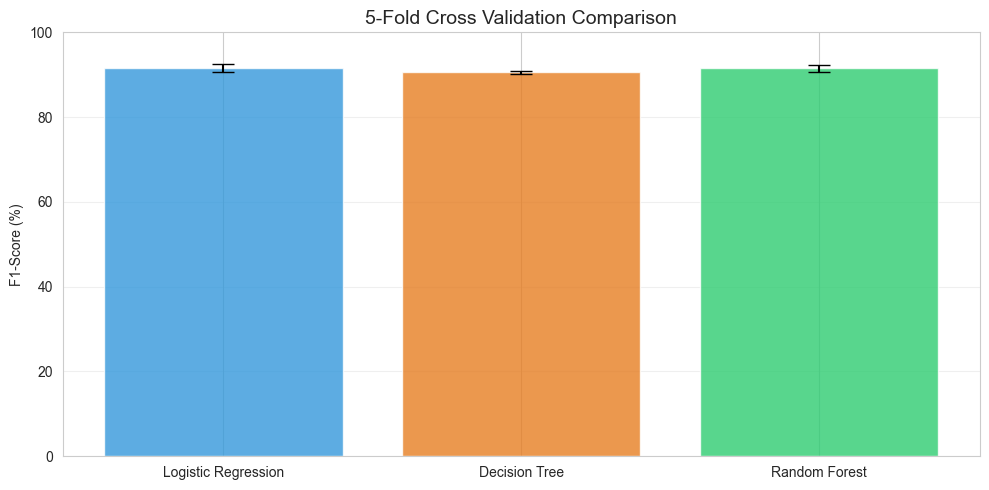

In [80]:
plt.figure(figsize=(10, 5))

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
means = [log_cv_scores.mean()*100, dt_cv_scores.mean()*100, rf_cv_scores.mean()*100]
stds  = [log_cv_scores.std()*100, dt_cv_scores.std()*100, rf_cv_scores.std()*100]

plt.bar(models, means, yerr=stds, capsize=8, color=["#3498db", "#e67e22", "#2ecc71"], alpha=0.8)
plt.ylabel("F1-Score (%)")
plt.title("5-Fold Cross Validation Comparison", fontsize=14)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## HANDLE CLASS IMBALANCE:

In [81]:
print("Class Distribution in Training Set:")
print(y_train.value_counts())
print("\nPercentage:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Class Distribution in Training Set:
Passed
1    1182
0     418
Name: count, dtype: int64

Percentage:
Passed
1    73.9
0    26.1
Name: proportion, dtype: float64


In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Decision Tree with balanced class weight
dt_balanced = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt_balanced.fit(X_train, y_train)

# Random Forest with balanced class weight
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_balanced.fit(X_train, y_train)

print("Models trained with class_weight='balanced'")

Models trained with class_weight='balanced'


In [83]:
print("===== Decision Tree (Balanced) =====")
print(classification_report(y_test, dt_balanced.predict(X_test), target_names=["Fail", "Pass"]))

print("===== Random Forest (Balanced) =====")
print(classification_report(y_test, rf_balanced.predict(X_test), target_names=["Fail", "Pass"]))

===== Decision Tree (Balanced) =====
              precision    recall  f1-score   support

        Fail       0.60      0.88      0.71       104
        Pass       0.95      0.79      0.86       296

    accuracy                           0.81       400
   macro avg       0.77      0.84      0.79       400
weighted avg       0.86      0.81      0.82       400

===== Random Forest (Balanced) =====
              precision    recall  f1-score   support

        Fail       0.74      0.86      0.79       104
        Pass       0.95      0.90      0.92       296

    accuracy                           0.89       400
   macro avg       0.84      0.88      0.86       400
weighted avg       0.89      0.89      0.89       400



In [86]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {1: 1182, 0: 418}
After SMOTE : {1: 1182, 0: 1182}


In [87]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

print("Random Forest trained on SMOTE data")
print(classification_report(y_test, rf_smote.predict(X_test), target_names=["Fail", "Pass"]))

Random Forest trained on SMOTE data
              precision    recall  f1-score   support

        Fail       0.72      0.81      0.76       104
        Pass       0.93      0.89      0.91       296

    accuracy                           0.87       400
   macro avg       0.82      0.85      0.83       400
weighted avg       0.87      0.87      0.87       400



In [88]:
print("===== Class Imbalance Handling Summary =====")
print("1. Original Model          → May have lower Recall on Fail class")
print("2. class_weight='balanced' → Simple and effective")
print("3. SMOTE                   → Creates synthetic minority samples")

===== Class Imbalance Handling Summary =====
1. Original Model          → May have lower Recall on Fail class
2. class_weight='balanced' → Simple and effective
3. SMOTE                   → Creates synthetic minority samples


##

## BUILD A WEB APP ( STEAMLIT / GRADIO ) 

In [89]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# -------------------------------
# Page Config
# -------------------------------
st.set_page_config(
    page_title="Student Performance Prediction",
    page_icon="🎓",
    layout="centered"
)

st.title("🎓 Student Performance Prediction & Early Warning System")
st.markdown("### Predict Pass/Fail + Risk Level using Machine Learning")

# -------------------------------
# Load Model & Scaler
# -------------------------------
@st.cache_resource
def load_models():
    model = joblib.load("best_student_model.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, scaler

try:
    model, scaler = load_models()
    model_loaded = True
except:
    st.error("Model files not found! Please make sure 'best_student_model.pkl' and 'scaler.pkl' are in the same folder.")
    model_loaded = False

# -------------------------------
# Input Form
# -------------------------------
st.sidebar.header("Enter Student Details")

age = st.sidebar.slider("Age", 18, 25, 20)
gender = st.sidebar.selectbox("Gender", ["Male", "Female"])
year = st.sidebar.selectbox("Year", [1, 2, 3, 4])
department = st.sidebar.selectbox("Department", ["CSE", "IT", "ECE", "ME", "EEE", "Civil", "AIML"])

hours_studied = st.sidebar.slider("Hours Studied (per week)", 0.5, 17.0, 6.0, 0.1)
attendance = st.sidebar.slider("Attendance (%)", 30.0, 100.0, 75.0, 0.5)
previous_marks = st.sidebar.slider("Previous Marks", 25.0, 98.0, 65.0, 0.5)
assignment_score = st.sidebar.slider("Assignment Score", 20.0, 100.0, 70.0, 0.5)
internal_marks = st.sidebar.slider("Internal Marks", 25.0, 100.0, 68.0, 0.5)
quiz_score = st.sidebar.slider("Quiz Score", 15.0, 100.0, 65.0, 0.5)
practical_score = st.sidebar.slider("Practical Score", 25.0, 100.0, 70.0, 0.5)
study_hours_per_day = st.sidebar.slider("Study Hours Per Day", 0.3, 9.5, 2.5, 0.1)
sleep_hours = st.sidebar.slider("Sleep Hours", 3.0, 10.5, 7.0, 0.1)
class_participation = st.sidebar.selectbox("Class Participation", ["Low", "Medium", "High"])
internet_usage = st.sidebar.slider("Internet Usage (hours/day)", 0.5, 12.0, 3.5, 0.1)

# -------------------------------
# Predict Button
# -------------------------------
if st.sidebar.button("Predict Performance", type="primary"):

    if not model_loaded:
        st.stop()

    # ---------- Preprocessing ----------
    gender_num = 0 if gender == "Male" else 1
    participation_num = {"Low": 0, "Medium": 1, "High": 2}[class_participation]

    # Create base features
    data = {
        "Age": age,
        "Gender": gender_num,
        "Year": year,
        "Hours_Studied": hours_studied,
        "Attendance": attendance,
        "Previous_Marks": previous_marks,
        "Assignment_Score": assignment_score,
        "Internal_Marks": internal_marks,
        "Quiz_Score": quiz_score,
        "Practical_Score": practical_score,
        "Study_Hours_Per_Day": study_hours_per_day,
        "Sleep_Hours": sleep_hours,
        "Class_Participation": participation_num,
        "Internet_Usage": internet_usage,
    }

    # Engineered features
    data["Study_Efficiency"] = previous_marks / (hours_studied + 1)
    data["Attendance_Level"] = 0 if attendance < 60 else (1 if attendance < 75 else 2)
    data["Academic_Consistency"] = (previous_marks + assignment_score + internal_marks + quiz_score) / 4

    # Department One-Hot Encoding
    departments = ["CSE", "IT", "ECE", "ME", "EEE", "Civil", "AIML"]
    for dept in departments:
        if dept != "CSE":   # drop_first=True was used (CSE as reference)
            data[f"Department_{dept}"] = 1 if department == dept else 0

    input_df = pd.DataFrame([data])

    # Reorder columns to match training data (very important)
    # You may need to adjust this list according to your actual X.columns
    expected_columns = list(model.feature_names_in_) if hasattr(model, "feature_names_in_") else input_df.columns
    input_df = input_df.reindex(columns=expected_columns, fill_value=0)

    # ---------- Prediction ----------
    try:
        # Check if model needs scaling (Logistic Regression)
        if "LogisticRegression" in str(type(model)):
            input_scaled = scaler.transform(input_df)
            prediction = model.predict(input_scaled)[0]
            probability = model.predict_proba(input_scaled)[0][1]
        else:
            prediction = model.predict(input_df)[0]
            probability = model.predict_proba(input_df)[0][1]

        # Risk Level
        if probability >= 0.75:
            risk = "Low Risk"
            risk_color = "green"
        elif probability >= 0.45:
            risk = "Medium Risk"
            risk_color = "orange"
        else:
            risk = "High Risk"
            risk_color = "red"

        # ---------- Display Results ----------
        st.markdown("---")
        st.subheader("Prediction Result")

        col1, col2, col3 = st.columns(3)

        with col1:
            st.metric("Prediction", "PASS" if prediction == 1 else "FAIL")

        with col2:
            st.metric("Pass Probability", f"{probability*100:.1f}%")

        with col3:
            st.markdown(f"**Risk Level**")
            st.markdown(f"<h3 style='color:{risk_color}'>{risk}</h3>", unsafe_allow_html=True)

        # Suggestions for High Risk
        if risk == "High Risk":
            st.warning("This student is at **High Risk** of failing.")
            st.markdown("""
            **Suggested Actions:**
            - Improve attendance immediately
            - Increase daily study hours
            - Complete all assignments on time
            - Seek help from teachers / mentors
            - Reduce excessive internet usage
            """)
        elif risk == "Medium Risk":
            st.info("This student is at **Medium Risk**. Regular monitoring is recommended.")
        else:
            st.success("This student is at **Low Risk**. Performance looks good!")

    except Exception as e:
        st.error(f"Prediction failed. Error: {e}")
        st.info("Make sure the feature columns match exactly with the training data.")

else:
    st.info("← Enter student details in the sidebar and click **Predict Performance**")

# -------------------------------
# Footer
# -------------------------------
st.markdown("---")
st.caption("Student Performance Prediction System | Machine Learning Project")

2026-09-09 20:20:42.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-09 20:20:42.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [90]:
print(X.columns.tolist())

['Age', 'Gender', 'Year', 'Hours_Studied', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Internal_Marks', 'Quiz_Score', 'Practical_Score', 'Study_Hours_Per_Day', 'Sleep_Hours', 'Class_Participation', 'Internet_Usage', 'Department_CSE', 'Department_Civil', 'Department_ECE', 'Department_EEE', 'Department_IT', 'Department_ME', 'Study_Efficiency', 'Attendance_Level', 'Academic_Consistency']
